In [598]:
import os
import platform

import pandas as pd
import numpy as np
from gensim.models import KeyedVectors
from pingouin import ancova
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multitest import multipletests

In [599]:
import warnings

# RuntimeWarning 무시
warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [600]:
os_system = platform.system() # 맥북은 Darwin, 윈도우는 Windows

# 현재 프로젝트 폴더 위치 지정. os.getcwd()는 지금 코드 실행하는 현 위치를 출력해줍니다.
research1_dir = os.getcwd()

# data/processed 폴더 위치 지정
processed_data_dir = research1_dir + ('\\data\\processed\\' if os_system == 'Windows' else '/data/processed/')

# boxplots 이미지 저장할 폴더 위치 지정
graph_image_dir = research1_dir + ('\\graph\\ancova' if os_system == 'Windows' else '/graph/ancova')
# 폴더 없으면 생성
os.makedirs(graph_image_dir, exist_ok=True)

In [601]:
# 테이블 읽어오기
similarity_data = pd.read_csv(processed_data_dir + 'similarity_coherence.csv', encoding='ISO-8859-1')
survey_data = pd.read_csv(processed_data_dir + 'survey_data.csv', encoding='ISO-8859-1')

## 그룹간 cosine similarity의 시행별 추이의 차이
### moving window적용

In [602]:
def calculate_moving_average(data, window_size=8, moving_size=4):
    moving_average_data = pd.DataFrame()
    index=1
    for i in range(0, len(data.columns) - window_size + 1, moving_size):
        window_data = data.iloc[:, i:i + window_size]
        window_mean = window_data.mean(axis=1) 
        moving_average_data[f'{index}'] = window_mean
        index += 1

    return moving_average_data

### ANCOVA 분석 준비

In [603]:
# ANCOVA 분석을 위해, 성별 컬럼을 categorical dummy value로 변경
def make_dummy_values_of_sex(data):
    data['sex_Male'] = (data['sex'] == 1).astype(int)
    data['sex_Female'] = (data['sex'] == 2).astype(int)

    return data

### ANCOVA

In [604]:
def analyze_ancova_for_each_column(data, column_len: int, between: str, covar: list):
    significant_0_05 = [] # p<0.5
    significant_0_01 = [] # p<0.1
    significant_0_001 = [] # p<0.01
    p_values = []
    
    # 각 열에 대한 ANCOVA 실행
    for column_number in range(1, column_len):
        ancova_result = ancova(data=data, dv=f'{column_number}', between=between, covar=covar)
        p_value = ancova_result['p-unc'][0]
        p_values.append((int(column_number), ancova_result['p-unc'][0]))

        print(f"Column {column_number} ANCOVA Results:")
        print(ancova_result)
        print()

        if p_value < 0.05:
            significant_0_05.append(column_number)
        if p_value < 0.01:
            significant_0_01.append(column_number)
        if p_value < 0.001:
            significant_0_001.append(column_number)

    return p_values, significant_0_05, significant_0_01, significant_0_001

### similairty line graph

In [605]:
def draw_similarity_line_graph(data, target_columns: list, significant_list: list, seed_word: str, filename: str):
    NA_low = data.loc[data['group_NA'] == 1].iloc[:, :len(target_columns)]
    NA_high = data.loc[data['group_NA'] == 2].iloc[:, :len(target_columns)]

    NA_low_datas = NA_low.mean()
    NA_high_datas = NA_high.mean()

    plt.figure(figsize=(8, 6))
    plt.plot(NA_high_datas, marker='.', color='#7a58a3', linestyle='-', label='NA High')
    plt.plot(NA_low_datas, marker='.', color='#73a69e', linestyle='--', label='NA low')

    # 유의한 점 표시
    for point in significant_list:
        plt.axvspan(point - 1.5, point - 0.5, alpha=0.2, color='gray')
        plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')
    # for point in significant_0_01:
    #     plt.axvspan(point - 1.5, point - 0.5, alpha=0.2, color='gray')
    #     plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')
    # for point in significant_0_001:
    #     plt.axvspan(point - 1.5, point - 0.5, alpha=0.2, color='gray')
    #     plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')

    plt.title(f'Seed word: {seed_word}')
    plt.ylim(0, 0.2)
    plt.legend(loc='upper right')

    plt.xticks(range(0, len(NA_low_datas), 4))

    filepath =  (f'\\{graph_image_dir}\\{filename}' if os_system == 'Windows' else f'/{graph_image_dir}/{filename}')
    plt.savefig(filepath, dpi=300)

    # plt.show()


### similairty smoothing graph

In [606]:
def draw_similarity_smoothing_graph(data, target_columns: list, significant_list: list, window_size: int, seed_word:str, filename: str):
    # 이동 평균 계산
    NA_low = data.loc[data['group_NA'] == 1].iloc[:, :len(target_columns)]
    NA_high = data.loc[data['group_NA'] == 2].iloc[:, :len(target_columns)]
    NA_low_smoothed_values = NA_low.mean().rolling(window=window_size).mean()
    NA_high_smoothed_values = NA_high.mean().rolling(window=window_size).mean()

    plt.figure(figsize=(8, 6))

    # 신뢰구간 
    confidence_interval = 1.96  # 95% 신뢰구간

    NA_low_sem = NA_low.sem()
    NA_high_sem = NA_high.sem()

    lower_bound_low = NA_low_smoothed_values - confidence_interval * NA_low_sem
    upper_bound_low = NA_low_smoothed_values + confidence_interval * NA_low_sem
    lower_bound_high = NA_high_smoothed_values - confidence_interval * NA_high_sem
    upper_bound_high = NA_high_smoothed_values + confidence_interval * NA_high_sem

    plt.fill_between(range(len(NA_low_smoothed_values)), lower_bound_low, upper_bound_low, color='#73a69e', alpha=0.3)
    plt.fill_between(range(len(NA_high_smoothed_values)), lower_bound_high, upper_bound_high, color='#7a58a3', alpha=0.3)

    # 스무딩 그래프
    plt.plot(NA_high_smoothed_values, color='#7a58a3', linestyle='-', label='NA High')
    plt.plot(NA_low_smoothed_values, color='#73a69e', linestyle='--', label='NA Low')

    # 유의한 점 표시
    for point in significant_list:
        plt.axvspan(point - 1.5, point - 0.5, alpha=0.2, color='gray')
    # for point in significant_0_01:
    #     plt.axvspan(point-0.5, point+0.5, alpha=0.2, color='gray')
    # for point in significant_0_001:
    #     plt.axvspan(point-0.5, point+0.5, alpha=0.2, color='gray')

    plt.title(f'Seed word: {seed_word}')
    plt.xlim(0, 9)
    plt.ylim(0, 0.2)
    plt.legend(loc='upper right')

    plt.xticks(range(0, len(NA_low_datas), 2))

    filepath =  (f'\\{graph_image_dir}\\{filename}' if os_system == 'Windows' else f'/{graph_image_dir}/{filename}')
    plt.savefig(filepath, dpi=300)

    # plt.show()

## multiple comparison

In [607]:
def benjamini_hochberg_correction(p_values, alpha=0.05):
    fdr_significant_0_05 = [] # p<0.5
    fdr_significant_0_01 = [] # p<0.1
    fdr_significant_0_001 = [] # p<0.01

    p_values = [item[1] for item in p_values]
    adjusted_p_values = multipletests(p_values, method='fdr_bh', alpha=alpha)[1]

    # 보정된 p-값과 원래 p-값 출력
    print("Benjamini-Hochberg (FDR) Corrected p-values:")
    print(adjusted_p_values)

    print("Original p-values:")
    print(p_values)

    for i, p_value in enumerate(adjusted_p_values):
        if p_value < 0.05:
            fdr_significant_0_05.append(i+1)
        if p_value < 0.01:
            fdr_significant_0_01.append(i+1)
        if p_value < 0.001:
            fdr_significant_0_001.append(i+1)

    return fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001

# main code

#### target: money

Column 1 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.000119    1   0.078215  7.799100e-01  0.000241
1         age  0.000248    1   0.163849  6.859047e-01  0.000505
2  sex_Female  0.037239    1  24.571943  1.156381e-06  0.070493
3    sex_Male  0.057984    1  38.260236  1.865436e-09  0.105615
4    Residual  0.491029  324        NaN           NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.000021    1   0.007486  9.311038e-01  0.000023
1         age  0.000959    1   0.347152  5.561417e-01  0.001074
2  sex_Female  0.054543    1  19.737651  1.221999e-05  0.057588
3    sex_Male  0.076488    1  27.679307  2.613363e-07  0.078931
4    Residual  0.892570  323        NaN           NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000853    1   0.329960  0.566081  0.001017
1         age  0.000370    1   0.14

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_14327/3807371990.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')


Benjamini-Hochberg (FDR) Corrected p-values:
[0.93110378 0.93110378 0.93110378 0.93110378 0.93110378 0.93110378
 0.93110378 0.24388361]
Original p-values:
[0.7799099560756863, 0.9311037769865071, 0.5660811052682607, 0.7486478390777994, 0.840361541121725, 0.7917122287626389, 0.7196246403657411, 0.030485451004199016]
[]


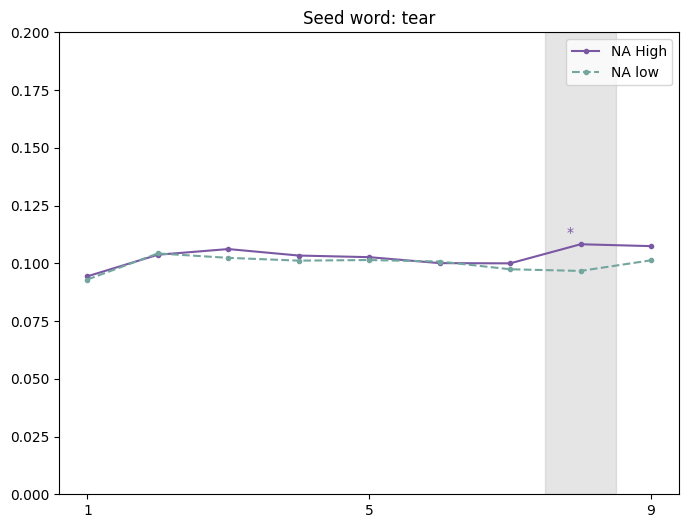

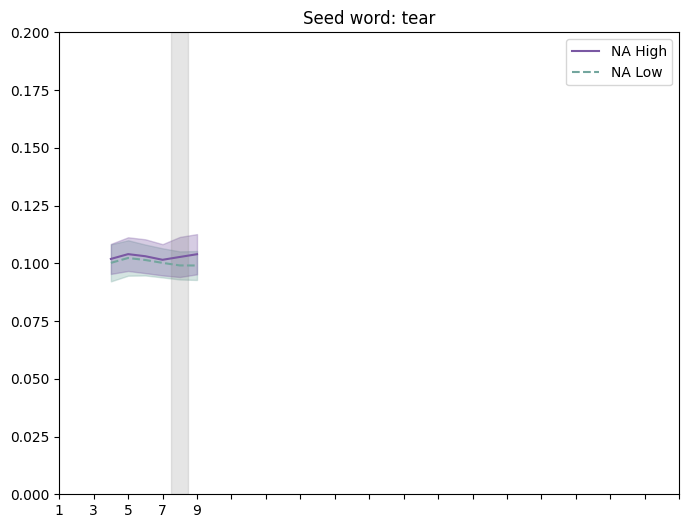

In [608]:
# moving average 계산
tear_money_ma = calculate_moving_average(data=similarity_data.iloc[:, 1:41])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
tear_money_df = make_dummy_values_of_sex(data = pd.concat([tear_money_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=tear_money_df,
                                                                  column_len=len(tear_money_ma.columns),
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])
print(significant_0_05)
# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=tear_money_df, target_columns=tear_money_ma.columns, significant_list=significant_0_05, seed_word='tear', filename='line_graph_tear_money.png')
draw_similarity_smoothing_graph(data=tear_money_df, target_columns=tear_money_ma.columns, significant_list=significant_0_05, window_size=4, seed_word='tear', filename='smoothing_graph_tear_money.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(fdr_significant_0_05)

In [609]:
# moving average 계산
family_money_ma = calculate_moving_average(data=similarity_data.iloc[:, 41:81])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
family_money_df = make_dummy_values_of_sex(data = pd.concat([family_money_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=family_money_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=family_money_df, significant_list=significant_0_05, seed_word='family', filename='line_graph_family_money.png')
draw_similarity_smoothing_graph(data=family_money_df, significant_list=significant_0_05, window_size=4, seed_word='family', filename='smoothing_graph_family_money.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

TypeError: analyze_ancova_for_each_column() missing 1 required positional argument: 'column_len'

Column 1 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000636    1   0.440687  0.507265  0.001362
1         age  0.000002    1   0.001385  0.970341  0.000004
2  sex_Female  0.027124    1  18.802433  0.000019  0.055010
3    sex_Male  0.034686    1  24.043838  0.000001  0.069282
4    Residual  0.465960  323        NaN       NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.003550    1   1.579773  0.209701  0.004867
1         age  0.001742    1   0.775309  0.379234  0.002395
2  sex_Female  0.014003    1   6.230814  0.013053  0.018925
3    sex_Male  0.032483    1  14.453884  0.000172  0.042832
4    Residual  0.725891  323        NaN       NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF         F     p-unc       np2
0    group_NA  0.012918    1  4.119987  0.043199  0.012595
1         age  0.011352    1  3.620779  0.057951  0.011086
2  sex_Female  0.002512   

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_14327/411913430.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')


Benjamini-Hochberg (FDR) Corrected p-values:
[0.79446005 0.64699718 0.44331612 0.44331612 0.52622446 0.70910462
 0.99347701 0.8310154  0.79446005 0.70910462 0.70910462 0.70910462
 0.79446005 0.79446005 0.70910462 0.84700484 0.99347701 0.84700484
 0.80124918 0.79446005 0.79446005 0.59561432 0.52622446 0.44515825
 0.44331612 0.44331612 0.64699718 0.70910462 0.79446005 0.8310154
 0.90100325 0.88676159 0.79446005 0.64699718 0.70910462 0.70910462
 0.64699718]
Original p-values:
[0.5072646458863316, 0.20970148471566666, 0.04319877147470616, 0.014586982336941334, 0.09590451823896062, 0.3732230011464096, 0.9934770111737974, 0.6921657692123261, 0.523768172095793, 0.34611546443671826, 0.3832997943945018, 0.3608993196802073, 0.5912876097103875, 0.5578825756650954, 0.35772234865453434, 0.7554367457508143, 0.9757069649525129, 0.7406130679571692, 0.628006117398102, 0.5555314393376584, 0.4609044821155692, 0.1287814744296554, 0.09955597809371926, 0.060156519787673585, 0.04792606656185657, 0.0402145829

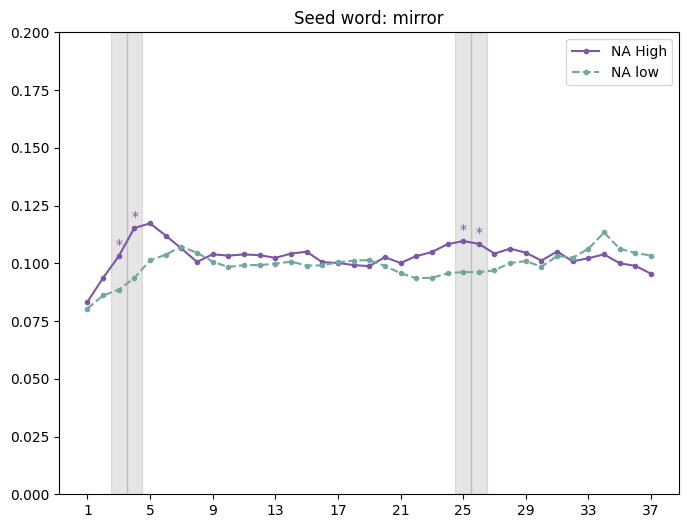

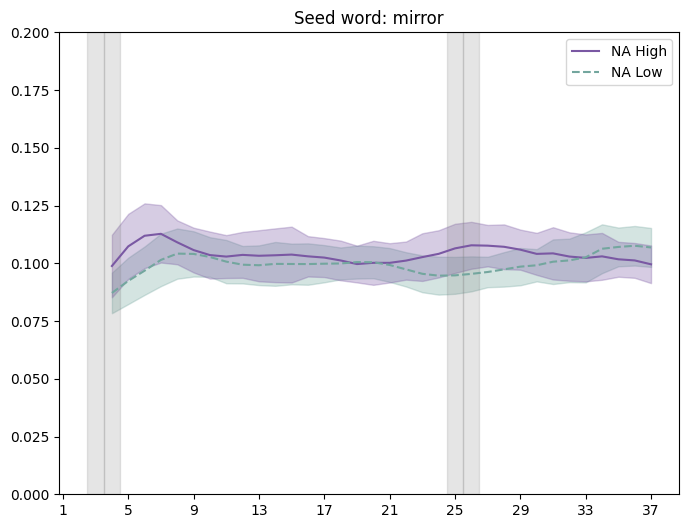

In [ ]:
# moving average 계산
mirror_money_ma = calculate_moving_average(data=similarity_data.iloc[:, 81:121])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
mirror_money_df = make_dummy_values_of_sex(data = pd.concat([mirror_money_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=mirror_money_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=mirror_money_df, significant_list=significant_0_05, seed_word='mirror', filename='line_graph_mirror_money.png')
draw_similarity_smoothing_graph(data=mirror_money_df, significant_list=significant_0_05, window_size=4, seed_word='mirror', filename='smoothing_graph_mirror_money.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

Column 1 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.000481    1   0.436237  5.094138e-01  0.001345
1         age  0.000700    1   0.635492  4.259317e-01  0.001958
2  sex_Female  0.037344    1  33.886855  1.405236e-08  0.094686
3    sex_Male  0.049433    1  44.857328  9.374120e-11  0.121612
4    Residual  0.357052  324        NaN           NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.000048    1   0.035620  8.504215e-01  0.000110
1         age  0.000622    1   0.464820  4.958667e-01  0.001433
2  sex_Female  0.035282    1  26.351094  4.918597e-07  0.075213
3    sex_Male  0.040979    1  30.605829  6.526044e-08  0.086309
4    Residual  0.433811  324        NaN           NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000570    1   0.255962  0.613252  0.000789
1         age  0.001383    1   0.62

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_14327/411913430.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')


Benjamini-Hochberg (FDR) Corrected p-values:
[0.72756189 0.89901696 0.81036877 0.55679066 0.72756189 0.72756189
 0.81779647 0.66682526 0.81779647 0.52153824 0.07446624 0.04110967
 0.00206735 0.01945902 0.07877141 0.07446624 0.17207158 0.22594305
 0.17286206 0.40029466 0.07446624 0.09232973 0.43973821 0.40996693
 0.81922251 0.68665495 0.52153824 0.72624098 0.52153824 0.96832466
 0.96832466 0.88673073 0.81779647 0.81779647 0.35507216 0.17286206
 0.35507216]
Original p-values:
[0.5094138073018635, 0.8504214513925614, 0.613252039361124, 0.31601632092588106, 0.519417548440787, 0.5309235440106296, 0.6648902126197562, 0.39649069719933183, 0.6935482336471448, 0.26976614603629917, 0.012075606851676012, 0.003333216765483846, 5.587442522536665e-05, 0.0010518391377129968, 0.014902699473214404, 0.01087727297727683, 0.04185524823990435, 0.07327882563186458, 0.05139142418492702, 0.16228162037017518, 0.011483847221575317, 0.01996318484271646, 0.20204188043675958, 0.17728299886480187, 0.730657911895986

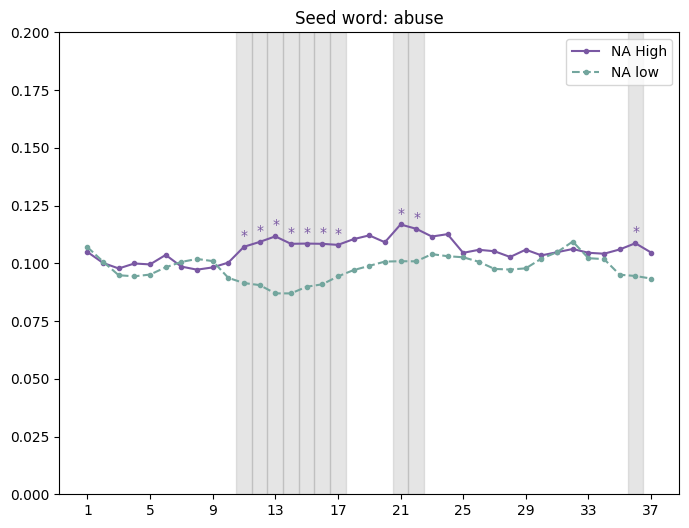

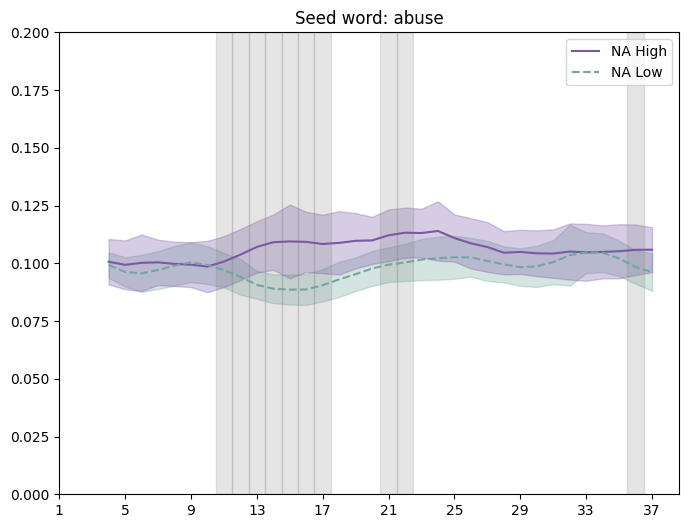

In [ ]:
# moving average 계산
abuse_money_ma = calculate_moving_average(data=similarity_data.iloc[:, 121:161])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
abuse_money_df = make_dummy_values_of_sex(data = pd.concat([abuse_money_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=abuse_money_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=abuse_money_df, significant_list=significant_0_05, seed_word='abuse', filename='line_graph_abuse_money.png')
draw_similarity_smoothing_graph(data=abuse_money_df, significant_list=significant_0_05, window_size=4, seed_word='abuse', filename='smoothing_graph_abuse_money.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

#### target: friend

Column 1 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.002535    1   0.499307  4.803124e-01  0.001539
1         age  0.002873    1   0.565960  4.524151e-01  0.001744
2  sex_Female  0.097947    1  19.292464  1.520903e-05  0.056198
3    sex_Male  0.126332    1  24.883481  9.951575e-07  0.071323
4    Residual  1.644928  324        NaN           NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.002514    1   0.570978  4.504195e-01  0.001759
1         age  0.005283    1   1.199946  2.741461e-01  0.003690
2  sex_Female  0.078994    1  17.940665  2.973389e-05  0.052467
3    sex_Male  0.136423    1  30.983845  5.462668e-08  0.087282
4    Residual  1.426589  324        NaN           NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.001352    1   0.270412  6.034106e-01  0.000834
1         age  0.001997    

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_14327/411913430.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')


Benjamini-Hochberg (FDR) Corrected p-values:
[0.86298772 0.86298772 0.86298772 0.86298772 0.86298772 0.86298772
 0.6882928  0.68264231 0.79093311 0.83564383 0.86298772 0.91973308
 0.86298772 0.86298772 0.79093311 0.79093311 0.68264231 0.79093311
 0.86298772 0.99558064 0.91973308 0.86298772 0.79093311 0.86298772
 0.86298772 0.86298772 0.68264231 0.68264231 0.68264231 0.79093311
 0.86298772 0.91973308 0.86298772 0.68264231 0.79093311 0.91973308
 0.86298772]
Original p-values:
[0.4803124100452406, 0.45041951822839255, 0.603410646172611, 0.5955717926314765, 0.7259696000831222, 0.3778065632066465, 0.1302175569658388, 0.09881301567803345, 0.24698957218056863, 0.33877452689654486, 0.58475466995932, 0.8209628893827867, 0.7302877185206884, 0.4434544553427574, 0.29798753613655105, 0.27205379795906476, 0.11069875346010138, 0.2992719859430022, 0.7463677575348713, 0.9955806370802271, 0.8564621470363363, 0.7219100723305301, 0.21054955183589358, 0.5470294544618224, 0.7434617648475237, 0.6121019067249

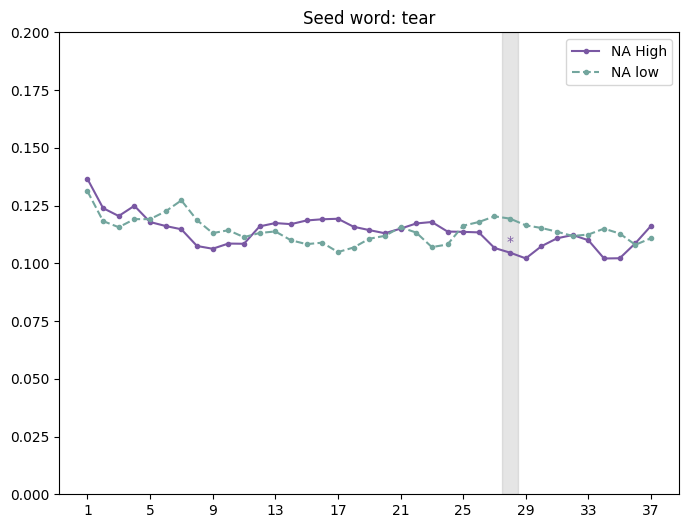

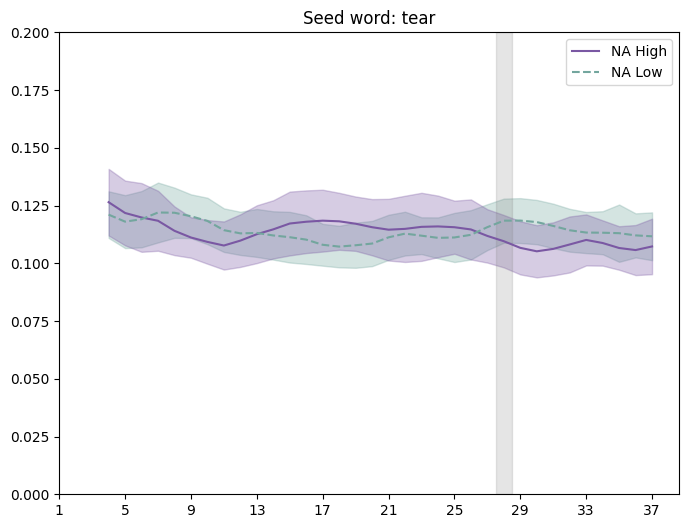

In [ ]:
# moving average 계산
tear_friend_ma = calculate_moving_average(data=similarity_data.iloc[:, 161:201])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
tear_friend_df = make_dummy_values_of_sex(data = pd.concat([tear_friend_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=tear_friend_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=tear_friend_df, significant_list=significant_0_05, seed_word='tear', filename='line_graph_tear_friend.png')
draw_similarity_smoothing_graph(data=tear_friend_df, significant_list=significant_0_05, window_size=4, seed_word='tear', filename='smoothing_graph_tear_friend.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

Column 1 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.018151    1   1.044161  3.076203e-01  0.003222
1         age  0.027625    1   1.589180  2.083532e-01  0.004896
2  sex_Female  0.405951    1  23.352849  2.087722e-06  0.067425
3    sex_Male  0.517790    1  29.786469  9.623462e-08  0.084432
4    Residual  5.614832  323        NaN           NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.004195    1   0.238183  0.625853  0.000737
1         age  0.002427    1   0.137819  0.710702  0.000427
2  sex_Female  0.152657    1   8.667196  0.003475  0.026132
3    sex_Male  0.304604    1  17.294105  0.000041  0.050821
4    Residual  5.689056  323        NaN       NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.002029    1   0.129662  0.719017  0.000400
1         age  0.000345    1   0.022016  0.882136  0.000068

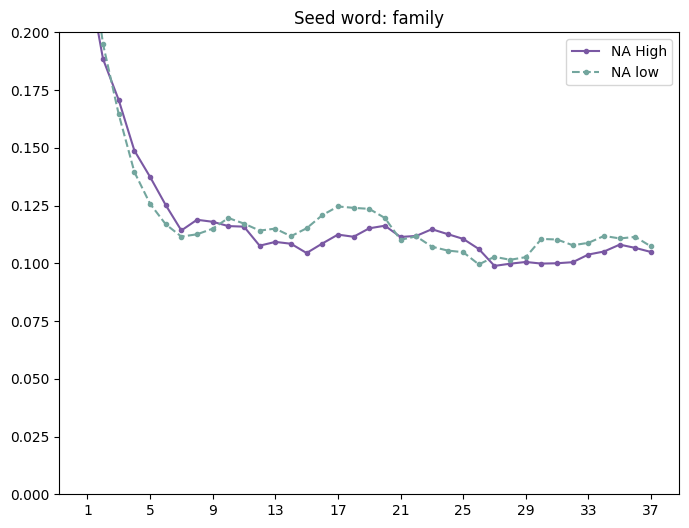

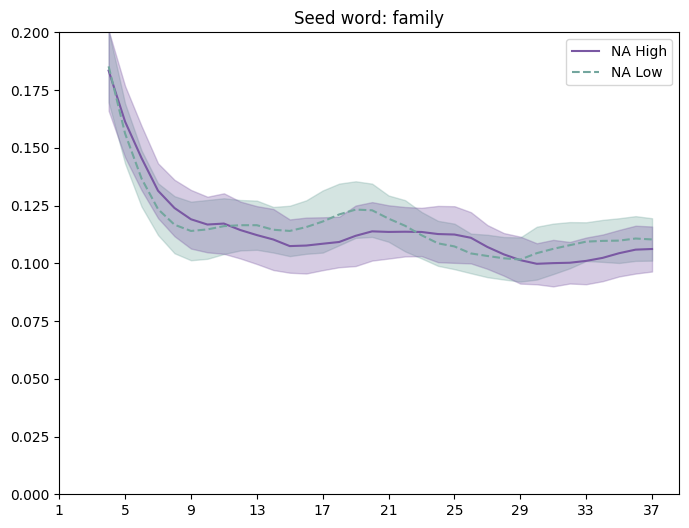

In [ ]:
# moving average 계산
family_friend_ma = calculate_moving_average(data=similarity_data.iloc[:, 201:241])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
family_friend_df = make_dummy_values_of_sex(data = pd.concat([family_friend_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=family_friend_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=family_friend_df, significant_list=significant_0_05, seed_word='family', filename='line_graph_family_friend.png')
draw_similarity_smoothing_graph(data=family_friend_df, significant_list=significant_0_05, window_size=4, seed_word='family', filename='smoothing_graph_family_friend.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

Column 1 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.009496    1   2.107125  0.147585  0.006481
1         age  0.001269    1   0.281654  0.595984  0.000871
2  sex_Female  0.035338    1   7.841604  0.005413  0.023702
3    sex_Male  0.049282    1  10.935931  0.001049  0.032749
4    Residual  1.455574  323        NaN       NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.001284    1   0.275221  0.600211  0.000851
1         age  0.002364    1   0.506464  0.477187  0.001566
2  sex_Female  0.031655    1   6.782973  0.009628  0.020568
3    sex_Male  0.046853    1  10.039654  0.001679  0.030146
4    Residual  1.507364  323        NaN       NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000071    1   0.014694  0.903594  0.000045
1         age  0.001122    1   0.231431  0.630790  0.000716
2  sex_Female  0.031026

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_14327/411913430.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')


Benjamini-Hochberg (FDR) Corrected p-values:
[0.6777148  0.94065944 0.94065944 0.94065944 0.88158158 0.94065944
 0.94065944 0.7216181  0.91539789 0.87029724 0.94065944 0.6777148
 0.6777148  0.6777148  0.6777148  0.94065944 0.94065944 0.94065944
 0.94065944 0.94065944 0.94065944 0.94065944 0.78952733 0.6777148
 0.6777148  0.94065944 0.6777148  0.88158158 0.87029724 0.6777148
 0.6777148  0.6777148  0.6777148  0.6777148  0.94065944 0.94065944
 0.94065944]
Original p-values:
[0.147585096101492, 0.6002105611112261, 0.903594154178728, 0.862467392388496, 0.45270405613047204, 0.570742038524017, 0.8257717244384907, 0.2730446882276271, 0.49480967057635483, 0.3933810406506093, 0.7616712587742598, 0.1683949619225437, 0.12963998506723007, 0.08930538022818005, 0.23811601062879495, 0.8525108140273461, 0.9406594403265673, 0.8518687023612264, 0.554747885574574, 0.9145548160335549, 0.8234080651305573, 0.6623389099602808, 0.320078649195047, 0.08789243121326831, 0.209407013803003, 0.8247490742713774, 0.12

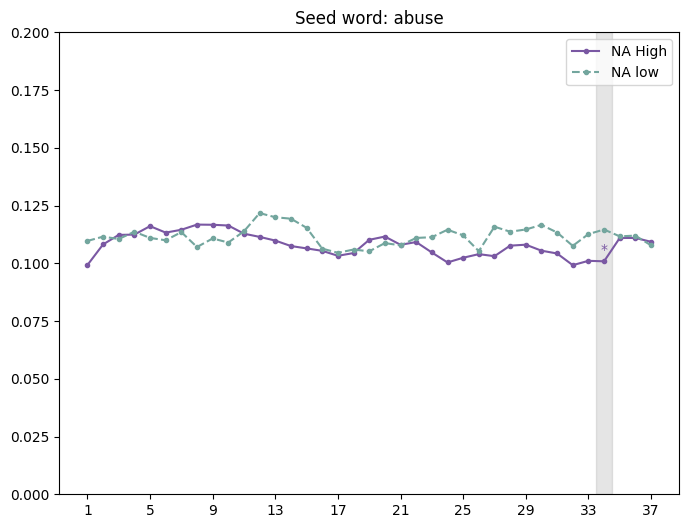

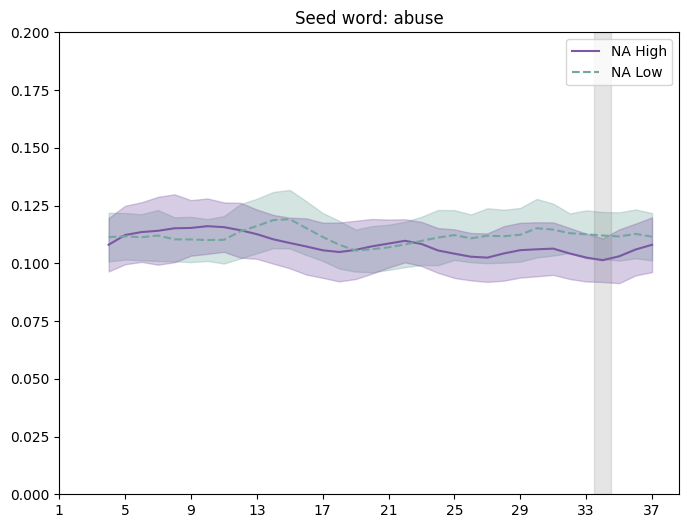

In [ ]:
# moving average 계산
mirror_friend_ma = calculate_moving_average(data=similarity_data.iloc[:, 241:281])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
mirror_friend_df = make_dummy_values_of_sex(data = pd.concat([mirror_friend_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=mirror_friend_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=mirror_friend_df, significant_list=significant_0_05, seed_word='abuse', filename='line_graph_mirror_friend.png')
draw_similarity_smoothing_graph(data=mirror_friend_df, significant_list=significant_0_05, window_size=4, seed_word='abuse', filename='smoothing_graph_mirror_friend.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

Column 1 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.010713    1   1.829548  0.177124  0.005615
1         age  0.000115    1   0.019594  0.888765  0.000060
2  sex_Female  0.076977    1  13.146587  0.000334  0.038994
3    sex_Male  0.141444    1  24.156719  0.000001  0.069385
4    Residual  1.897108  324        NaN       NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.004884    1   0.790842  3.745055e-01  0.002435
1         age  0.005994    1   0.970577  3.252713e-01  0.002987
2  sex_Female  0.106438    1  17.234359  4.228773e-05  0.050506
3    sex_Male  0.174633    1  28.276409  1.963809e-07  0.080268
4    Residual  2.000997  324        NaN           NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.004648    1   0.702482  0.402569  0.002163
1         age  0.003415    1   0.516069  0.473041  0.001590

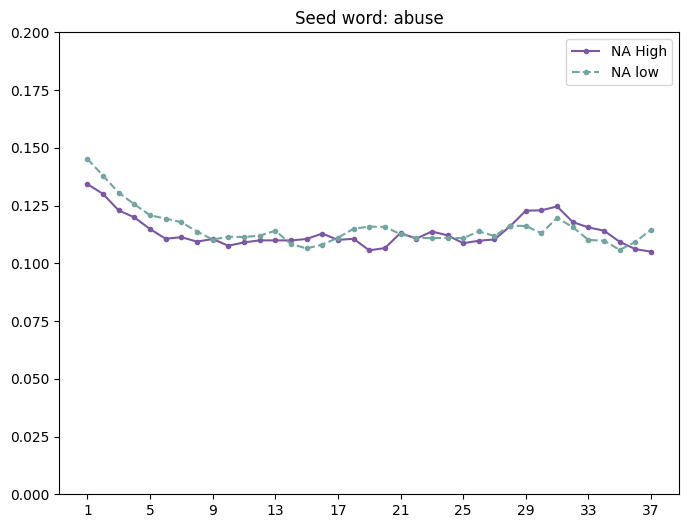

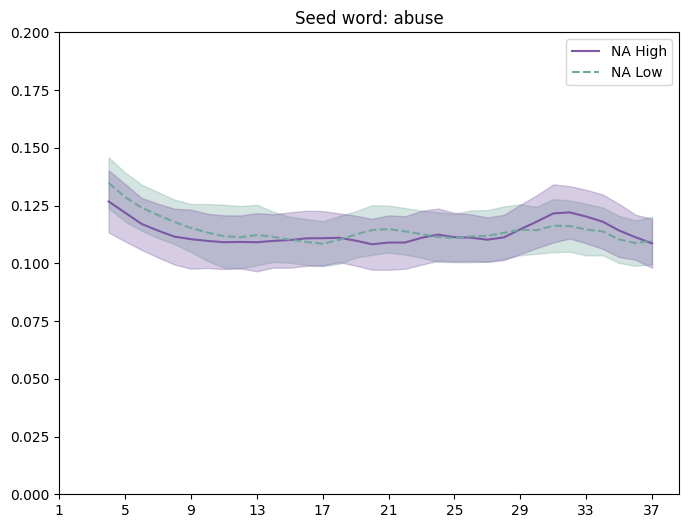

In [ ]:
# moving average 계산
abuse_friend_ma = calculate_moving_average(data=similarity_data.iloc[:, 281:321])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
abuse_friend_df = make_dummy_values_of_sex(data = pd.concat([abuse_friend_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=abuse_friend_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=abuse_friend_df, significant_list=significant_0_05, seed_word='abuse', filename='line_graph_abuse_friend.png')
draw_similarity_smoothing_graph(data=abuse_friend_df, significant_list=significant_0_05, window_size=4, seed_word='abuse', filename='smoothing_graph_abuse_friend.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

#### target: relationships

Column 1 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.001069    1   0.478732  0.489493  0.001475
1         age  0.001648    1   0.737874  0.390978  0.002272
2  sex_Female  0.039888    1  17.860356  0.000031  0.052245
3    sex_Male  0.034991    1  15.667775  0.000093  0.046127
4    Residual  0.723597  324        NaN       NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.001263    1   0.583570  0.445472  0.001798
1         age  0.003024    1   1.396678  0.238147  0.004292
2  sex_Female  0.050141    1  23.160495  0.000002  0.066714
3    sex_Male  0.034729    1  16.041631  0.000077  0.047175
4    Residual  0.701445  324        NaN       NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.001833    1   0.864098  0.353287  0.002660
1         age  0.000421    1   0.198596  0.656154  0.000613
2  sex_Female  0.039542

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_14327/411913430.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')


Benjamini-Hochberg (FDR) Corrected p-values:
[0.5659759  0.5659759  0.50754814 0.79800628 0.50754814 0.48599723
 0.47370792 0.50754814 0.76205653 0.50754814 0.53155009 0.50754814
 0.50754814 0.5659759  0.32731124 0.27567154 0.50754814 0.5659759
 0.67258446 0.50754814 0.50754814 0.15418956 0.15418956 0.13316924
 0.15418956 0.13316924 0.13316924 0.15418956 0.13316924 0.15418956
 0.15418956 0.15418956 0.27567154 0.50754814 0.76205653 0.68415399
 0.50754814]
Original p-values:
[0.4894926700056622, 0.4454721529533575, 0.3532865274002879, 0.7980062836063172, 0.2733603228875763, 0.21016096269341647, 0.19204375318435937, 0.34123022849803086, 0.741460411809626, 0.2787670569048664, 0.40225412414584794, 0.3570632903541222, 0.29156626419096326, 0.4876856818571125, 0.12384749564908094, 0.09168237649841633, 0.3154730640852866, 0.4623594880880222, 0.5998726301689383, 0.3456595987662834, 0.26764151767467637, 0.04584013885741392, 0.02820989476216047, 0.011936332754439297, 0.03461729748595046, 0.0119064

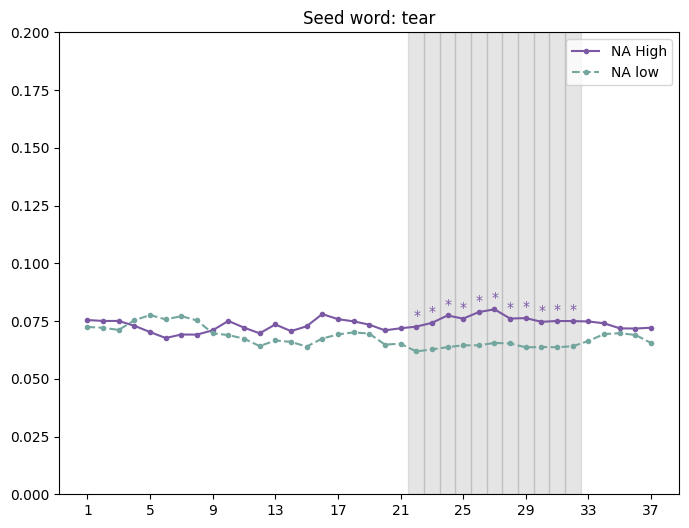

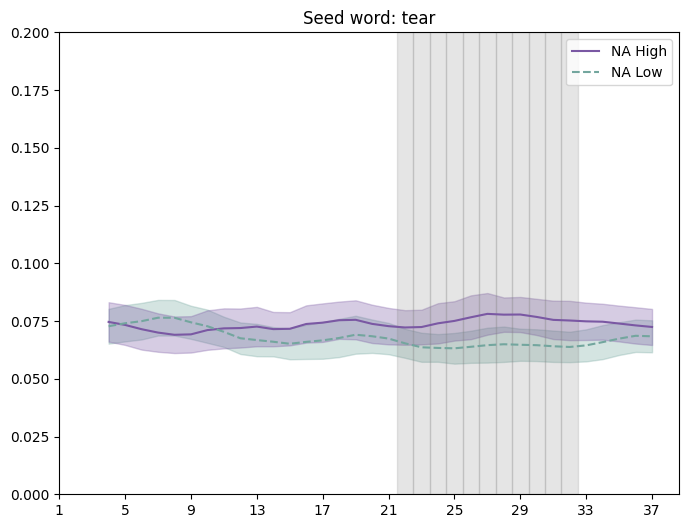

In [ ]:
# moving average 계산
tear_relationships_ma = calculate_moving_average(data=similarity_data.iloc[:, 321:361])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
tear_relationships_df = make_dummy_values_of_sex(data = pd.concat([tear_relationships_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=tear_relationships_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=tear_relationships_df, significant_list=significant_0_05, seed_word='tear', filename='line_graph_tear_relationships.png')
draw_similarity_smoothing_graph(data=tear_relationships_df, significant_list=significant_0_05, window_size=4, seed_word='tear', filename='smoothing_graph_tear_relationships.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

Column 1 ANCOVA Results:
       Source        SS   DF         F     p-unc       np2
0    group_NA  0.006728    1  2.363295  0.125199  0.007264
1         age  0.023644    1  8.305582  0.004217  0.025069
2  sex_Female  0.002916    1  1.024295  0.312260  0.003161
3    sex_Male  0.006584    1  2.312970  0.129277  0.007110
4    Residual  0.919507  323       NaN       NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF         F     p-unc       np2
0    group_NA  0.006312    1  2.051397  0.153034  0.006311
1         age  0.028404    1  9.231332  0.002573  0.027786
2  sex_Female  0.000034    1  0.011055  0.916330  0.000034
3    sex_Male  0.003134    1  1.018416  0.313651  0.003143
4    Residual  0.993838  323       NaN       NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF         F     p-unc       np2
0    group_NA  0.002032    1  0.643868  0.422902  0.001983
1         age  0.021973    1  6.962149  0.008727  0.021036
2  sex_Female  0.000005    1  0.001688

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_14327/411913430.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')


Benjamini-Hochberg (FDR) Corrected p-values:
[0.56622456 0.56622456 0.76322794 0.95297138 0.97613607 0.76322794
 0.62715502 0.76322794 0.76322794 0.95297138 0.95897143 0.93356705
 0.84593719 0.44619586 0.44619586 0.44619586 0.44619586 0.44619586
 0.60975462 0.62715502 0.98428211 0.93356705 0.62715502 0.76322794
 0.60975462 0.77406956 0.95297138 0.62715502 0.56622456 0.76322794
 0.95897143 0.95742352 0.93356705 0.76322794 0.44619586 0.60975462
 0.50097821]
Original p-values:
[0.12519855852607426, 0.15303366450362096, 0.4229016498693675, 0.8202723149408667, 0.9497540100642365, 0.49506676913074676, 0.2764070189226496, 0.4679916394930629, 0.49299436541778274, 0.8144607414161935, 0.8968826080289948, 0.7317147169506936, 0.5944423523443779, 0.07235608593327436, 0.0431341186865176, 0.024167456279916177, 0.02170486069461266, 0.05748581525849564, 0.1815930105232457, 0.2881523056148131, 0.9842821069661426, 0.7236429206115378, 0.26030005589107086, 0.4029663326628068, 0.21423811099365905, 0.5230199

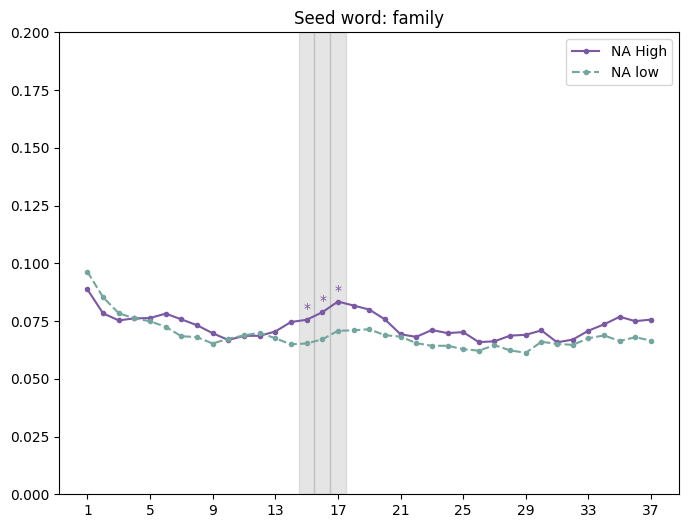

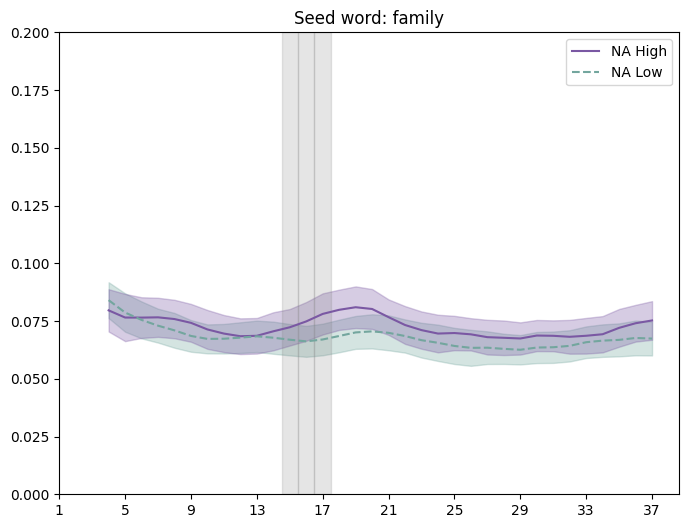

In [ ]:
# moving average 계산
family_relationships_ma = calculate_moving_average(data=similarity_data.iloc[:, 361:401])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
family_relationships_df = make_dummy_values_of_sex(data = pd.concat([family_relationships_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=family_relationships_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=family_relationships_df, significant_list=significant_0_05, seed_word='family', filename='line_graph_family_relationships.png')
draw_similarity_smoothing_graph(data=family_relationships_df, significant_list=significant_0_05, window_size=4, seed_word='family', filename='smoothing_graph_family_relationships.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

Column 1 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000849    1   0.457490  0.499283  0.001414
1         age  0.002603    1   1.402849  0.237118  0.004324
2  sex_Female  0.032008    1  17.249421  0.000042  0.050696
3    sex_Male  0.035032    1  18.879149  0.000019  0.055222
4    Residual  0.599351  323        NaN       NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000426    1   0.177307  0.673977  0.000549
1         age  0.000985    1   0.410066  0.522390  0.001268
2  sex_Female  0.025678    1  10.691151  0.001193  0.032039
3    sex_Male  0.031752    1  13.220202  0.000322  0.039320
4    Residual  0.775776  323        NaN       NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.002936    1   1.116662  0.291428  0.003445
1         age  0.000539    1   0.204950  0.651059  0.000634
2  sex_Female  0.019337

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_14327/411913430.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')


Benjamini-Hochberg (FDR) Corrected p-values:
[0.63517669 0.77928646 0.51346846 0.51346846 0.37674867 0.37674867
 0.42411311 0.37674867 0.59622978 0.59622978 0.61690473 0.94369156
 0.93429857 0.9401264  0.79317834 0.61690473 0.40145603 0.37674867
 0.37674867 0.37674867 0.51346846 0.37674867 0.37674867 0.48583035
 0.51346846 0.37674867 0.37674867 0.48583035 0.61690473 0.77928646
 0.51346846 0.48583035 0.63517669 0.61690473 0.93429857 0.51346846
 0.61690473]
Original p-values:
[0.49928321869990155, 0.6739774798351774, 0.2914280436801191, 0.28697321530488523, 0.029136880149051466, 0.01860871705539813, 0.13755019861946396, 0.05220745988034162, 0.37062932293846074, 0.3657118050574206, 0.4668468260692722, 0.9436915631154803, 0.8837959487384621, 0.9147175798910594, 0.7074293333181629, 0.4623088163919902, 0.1193517931329884, 0.05985023649361976, 0.06527507063886004, 0.10017914456945308, 0.22799531357050923, 0.10182396545235745, 0.0843064915966811, 0.19695824968555886, 0.24426179503191967, 0.088

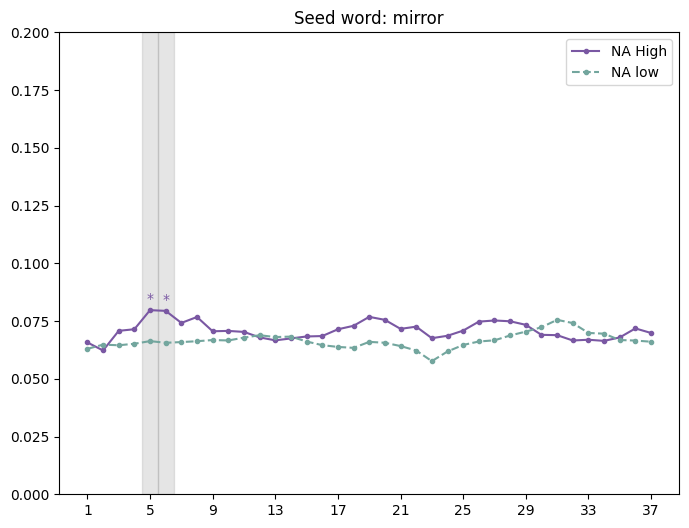

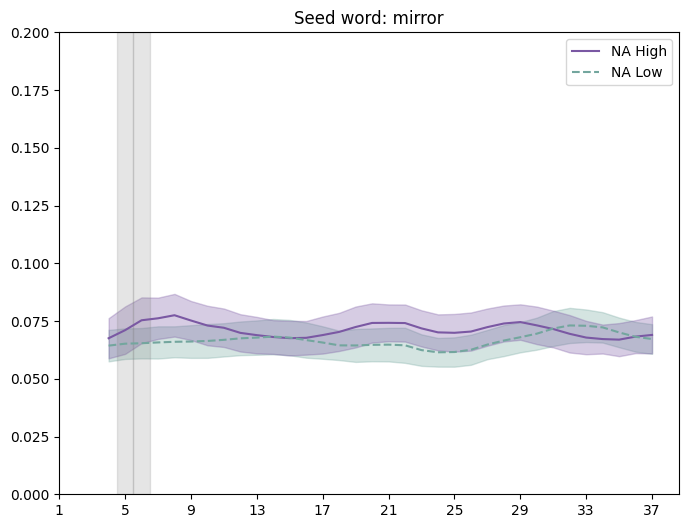

In [ ]:
# moving average 계산
mirror_relationships_ma = calculate_moving_average(data=similarity_data.iloc[:, 401:441])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
mirror_relationships_df = make_dummy_values_of_sex(data = pd.concat([mirror_relationships_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=mirror_relationships_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=mirror_relationships_df, significant_list=significant_0_05, seed_word='mirror', filename='line_graph_mirror_relationships.png')
draw_similarity_smoothing_graph(data=mirror_relationships_df, significant_list=significant_0_05, window_size=4, seed_word='mirror', filename='smoothing_graph_mirror_relationships.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

Column 1 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000669    1   0.381488  0.537242  0.001176
1         age  0.002316    1   1.320116  0.251419  0.004058
2  sex_Female  0.011428    1   6.512697  0.011169  0.019705
3    sex_Male  0.018132    1  10.333229  0.001438  0.030907
4    Residual  0.568534  324        NaN       NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF         F     p-unc       np2
0    group_NA  0.000400    1  0.170912  0.679576  0.000527
1         age  0.002235    1  0.955820  0.328972  0.002941
2  sex_Female  0.012817    1  5.481778  0.019821  0.016638
3    sex_Male  0.010133    1  4.334061  0.038142  0.013200
4    Residual  0.757531  324       NaN       NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000426    1   0.169923  0.680453  0.000524
1         age  0.000048    1   0.019246  0.889749  0.000059
2  sex_Female  0.027460    1 

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_14327/411913430.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')


Benjamini-Hochberg (FDR) Corrected p-values:
[0.82824794 0.93247288 0.93247288 0.72404547 0.86633024 0.98569524
 0.96374091 0.9518266  0.76273243 0.38250654 0.76273243 0.9518266
 0.9518266  0.9518266  0.76273243 0.31932643 0.16316617 0.05512933
 0.11173221 0.18283315 0.34545256 0.71095479 0.9518266  0.9518266
 0.76273243 0.60800378 0.9518266  0.9518266  0.77162058 0.71095479
 0.71095479 0.18283315 0.14002295 0.05512933 0.0338188  0.11173221
 0.24529828]
Original p-values:
[0.5372419099716604, 0.6795756057138334, 0.6804531809209733, 0.35223833658785186, 0.5853582729330402, 0.9856952421797491, 0.937693856461055, 0.8998046576661389, 0.41244653420310096, 0.13439418938557326, 0.40843366089273736, 0.9003765088806467, 0.8438949917152889, 0.882025835487184, 0.4535165787912623, 0.09493488317926743, 0.030869275874389552, 0.0033223505004210062, 0.015098946746531844, 0.04447292775357007, 0.11203866905357696, 0.3140378855667354, 0.8926868117607965, 0.8788690610621253, 0.44072051287965175, 0.2300554

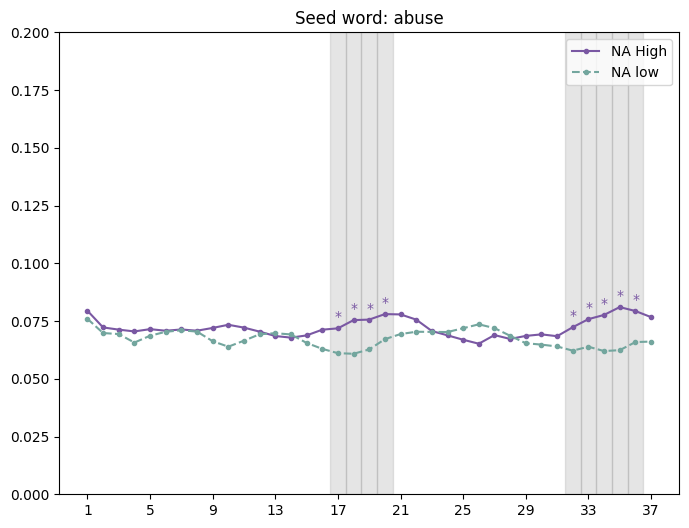

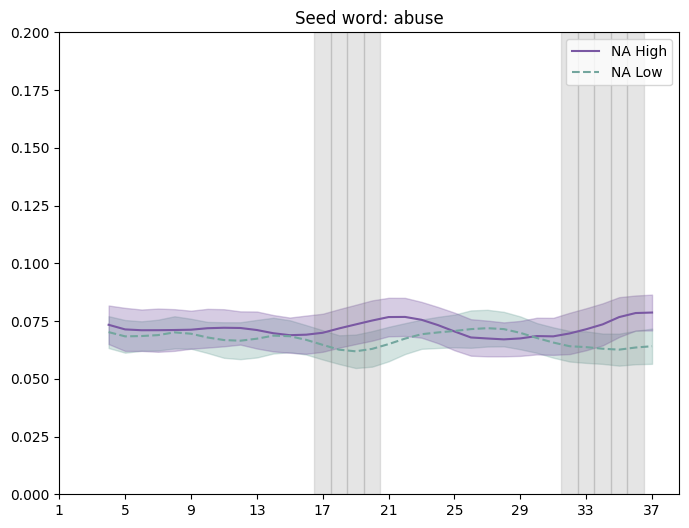

In [ ]:
# moving average 계산
abuse_relationships_ma = calculate_moving_average(data=similarity_data.iloc[:, 441:481])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
abuse_relationships_df = make_dummy_values_of_sex(data = pd.concat([abuse_relationships_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=abuse_relationships_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=abuse_relationships_df, significant_list=significant_0_05, seed_word='abuse', filename='line_graph_abuse_relationships.png')
draw_similarity_smoothing_graph(data=abuse_relationships_df, significant_list=significant_0_05, window_size=4, seed_word='abuse', filename='smoothing_graph_abuse_relationships.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

#### target: family

Column 1 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000280    1   0.053241  0.817662  0.000164
1         age  0.000124    1   0.023580  0.878054  0.000073
2  sex_Female  0.058246    1  11.075205  0.000976  0.033053
3    sex_Male  0.093789    1  17.833444  0.000031  0.052170
4    Residual  1.703972  324        NaN       NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000118    1   0.025679  0.872788  0.000079
1         age  0.001709    1   0.372793  0.541914  0.001149
2  sex_Female  0.057332    1  12.506532  0.000465  0.037166
3    sex_Male  0.102417    1  22.341221  0.000003  0.064506
4    Residual  1.485282  324        NaN       NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.000543    1   0.115769  0.733890  0.000357
1         age  0.000452    1   0.096414  0.756376  0.000297
2  sex_Female  0.029116

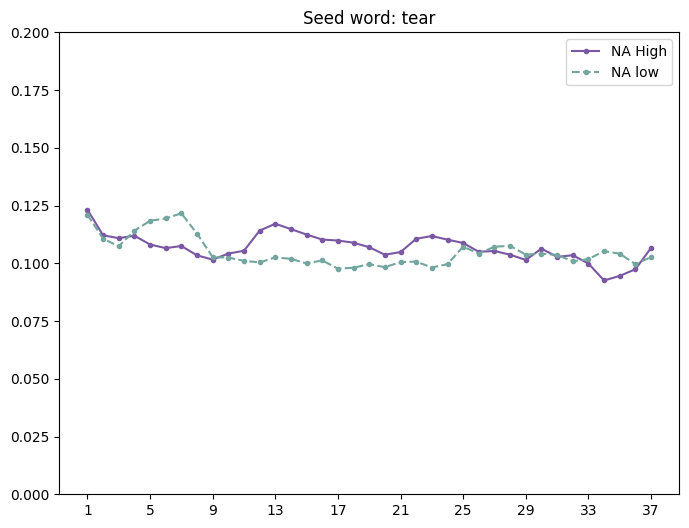

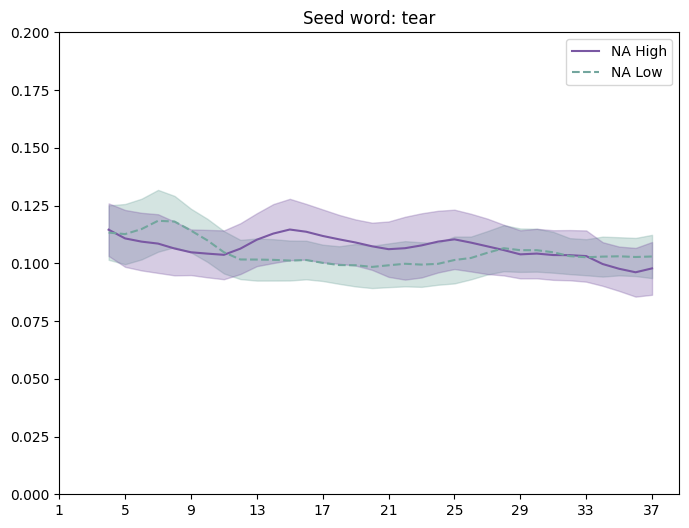

In [ ]:
# moving average 계산
tear_family_ma = calculate_moving_average(data=similarity_data.iloc[:, 481:521])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
tear_family_df = make_dummy_values_of_sex(data = pd.concat([tear_family_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=tear_family_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=tear_family_df, significant_list=significant_0_05, seed_word='tear', filename='line_graph_tear_family.png')
draw_similarity_smoothing_graph(data=tear_family_df, significant_list=significant_0_05, window_size=4, seed_word='tear', filename='smoothing_graph_tear_family.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

Column 1 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.023423    1   1.384608  0.240184  0.004268
1         age  0.006614    1   0.390959  0.532237  0.001209
2  sex_Female  0.333134    1  19.692929  0.000012  0.057465
3    sex_Male  0.409190    1  24.188899  0.000001  0.069671
4    Residual  5.464009  323        NaN       NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.014158    1   0.919206  0.338401  0.002838
1         age  0.000676    1   0.043915  0.834144  0.000136
2  sex_Female  0.117516    1   7.629927  0.006069  0.023077
3    sex_Male  0.202956    1  13.177267  0.000329  0.039197
4    Residual  4.974843  323        NaN       NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.003553    1   0.276450  0.599397  0.000853
1         age  0.000438    1   0.034094  0.853622  0.000105
2  sex_Female  0.084063

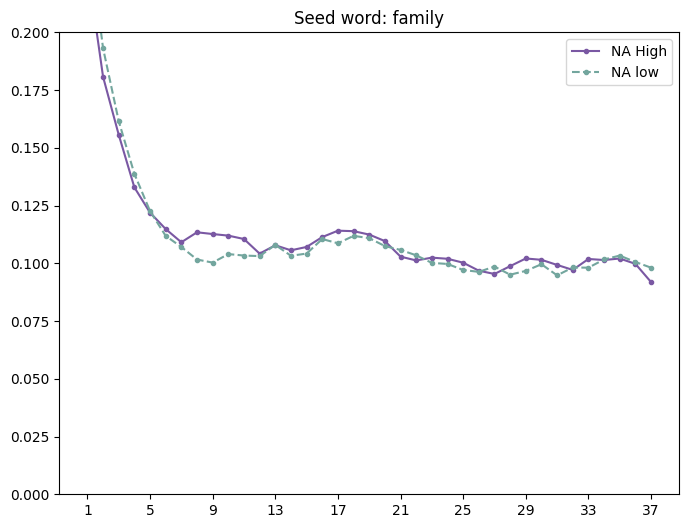

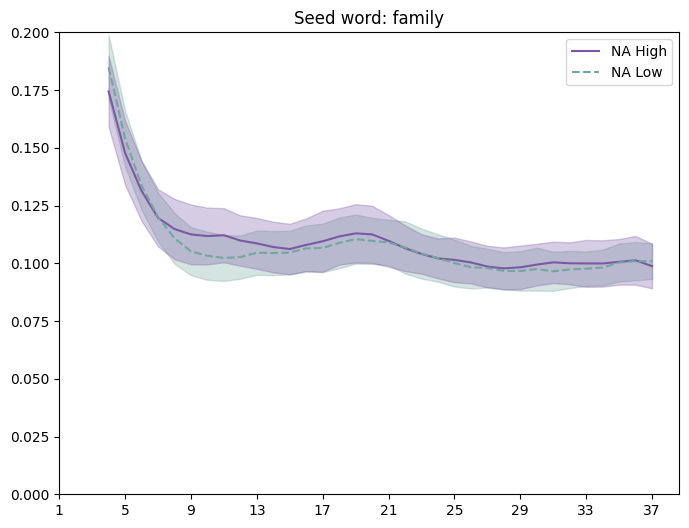

In [ ]:
# moving average 계산
family_family_ma = calculate_moving_average(data=similarity_data.iloc[:, 521:561])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
family_family_df = make_dummy_values_of_sex(data = pd.concat([family_family_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=family_family_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=family_family_df, significant_list=significant_0_05, seed_word='family', filename='line_graph_family_family.png')
draw_similarity_smoothing_graph(data=family_family_df, significant_list=significant_0_05, window_size=4, seed_word='family', filename='smoothing_graph_family_family.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

Column 1 ANCOVA Results:
       Source        SS   DF         F     p-unc       np2
0    group_NA  0.000876    1  0.320895  0.571464  0.000992
1         age  0.005783    1  2.118845  0.146467  0.006517
2  sex_Female  0.009404    1  3.445380  0.064339  0.010554
3    sex_Male  0.012660    1  4.638180  0.032008  0.014156
4    Residual  0.881630  323       NaN       NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF         F     p-unc       np2
0    group_NA  0.000550    1  0.139652  0.708872  0.000432
1         age  0.009001    1  2.285977  0.131526  0.007028
2  sex_Female  0.006985    1  1.774001  0.183827  0.005462
3    sex_Male  0.016331    1  4.147624  0.042508  0.012678
4    Residual  1.271756  323       NaN       NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF         F     p-unc       np2
0    group_NA  0.012351    1  2.683187  0.102386  0.008239
1         age  0.004914    1  1.067557  0.302271  0.003294
2  sex_Female  0.011153    1  2.422943

/var/folders/99/w9lwt31s6gzbvts3vs5x6myr0000gn/T/ipykernel_14327/411913430.py:15: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(point-1.2, NA_high_datas[point-1] + 0.003, '*', fontsize=10, color='#7a58a3')


Benjamini-Hochberg (FDR) Corrected p-values:
[0.93471429 0.93471429 0.63629287 0.71792382 0.63629287 0.70852607
 0.94210456 0.77990882 0.98023576 0.94210456 0.93471429 0.70852607
 0.63629287 0.66516465 0.77990882 0.93471429 0.94210456 0.98023576
 0.89709196 0.93471429 0.93471429 0.93471429 0.94210456 0.94210456
 0.77990882 0.77990882 0.94210456 0.93471429 0.77990882 0.70852607
 0.70852607 0.63629287 0.63629287 0.63629287 0.77990882 0.77990882
 0.93471429]
Original p-values:
[0.5714638050341101, 0.7088724193161244, 0.10238633963530999, 0.23284015629984342, 0.06742058201409659, 0.17539939090850507, 0.8911799913510097, 0.3607198585385325, 0.9695557380959746, 0.8633996614590878, 0.6573526134479222, 0.1963787567939422, 0.08728532903365167, 0.1258419601227911, 0.32119672461509907, 0.7326139010598849, 0.8154942556218714, 0.9802357628412307, 0.48491457543890304, 0.7014053378788002, 0.6678973093496868, 0.5767009805894011, 0.8707272651357122, 0.8822101023653717, 0.36995062628142483, 0.3216493916

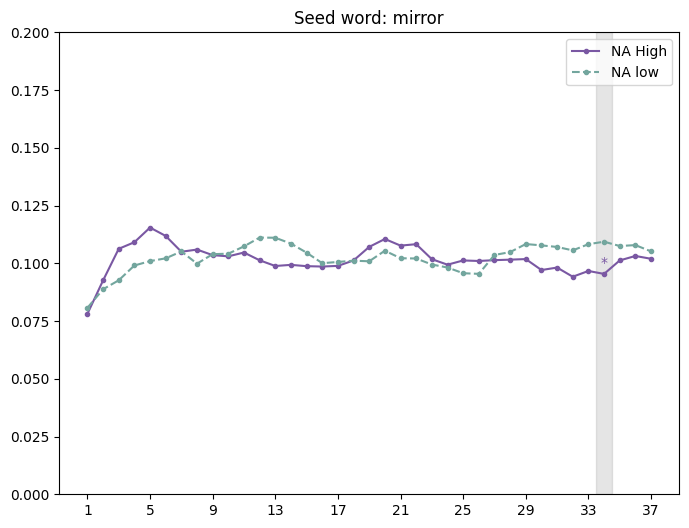

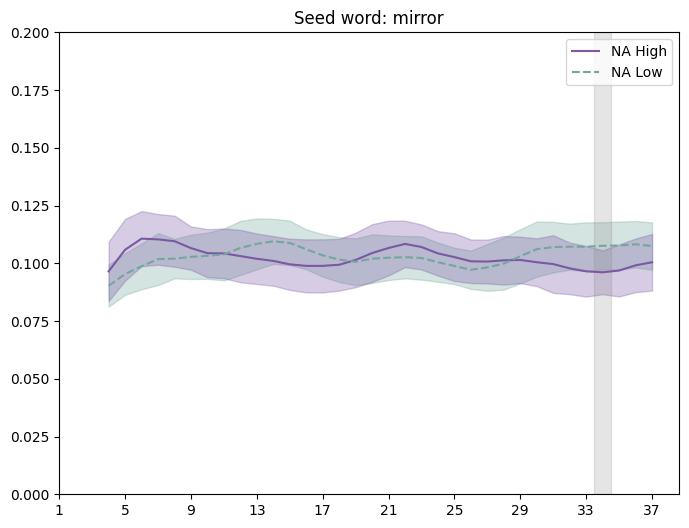

In [ ]:
# moving average 계산
mirror_family_ma = calculate_moving_average(data=similarity_data.iloc[:, 561:601])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
mirror_family_df = make_dummy_values_of_sex(data = pd.concat([mirror_family_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=mirror_family_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=mirror_family_df, significant_list=significant_0_05, seed_word='mirror', filename='line_graph_mirror_family.png')
draw_similarity_smoothing_graph(data=mirror_family_df, significant_list=significant_0_05, window_size=4, seed_word='mirror', filename='smoothing_graph_mirror_family.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

Column 1 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.006233    1   0.780021  3.777895e-01  0.002402
1         age  0.005263    1   0.658573  4.176601e-01  0.002029
2  sex_Female  0.156877    1  19.631639  1.286375e-05  0.057130
3    sex_Male  0.246898    1  30.896924  5.690587e-08  0.087059
4    Residual  2.589088  324        NaN           NaN       NaN

Column 2 ANCOVA Results:
       Source        SS   DF          F         p-unc       np2
0    group_NA  0.005571    1   0.756595  3.850400e-01  0.002330
1         age  0.017285    1   2.347413  1.264669e-01  0.007193
2  sex_Female  0.171083    1  23.233805  2.208946e-06  0.066911
3    sex_Male  0.228798    1  31.071771  5.241473e-08  0.087508
4    Residual  2.385783  324        NaN           NaN       NaN

Column 3 ANCOVA Results:
       Source        SS   DF          F     p-unc       np2
0    group_NA  0.002481    1   0.368239  0.544391  0.001135
1         age  0.005547    1   0.82

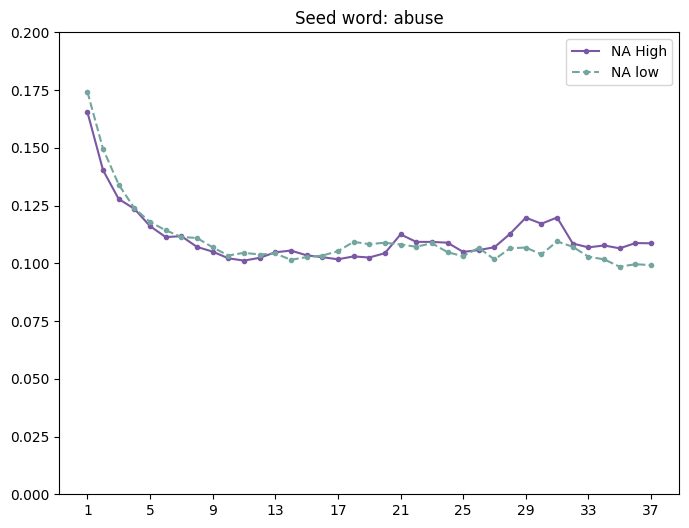

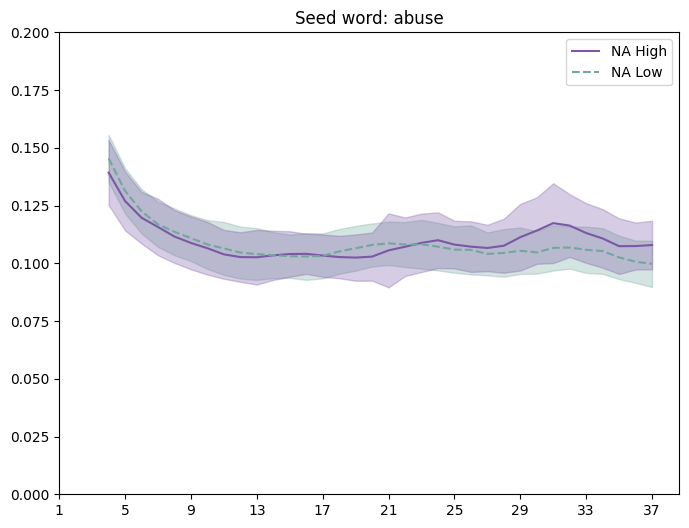

In [ ]:
# moving average 계산
abuse_family_ma = calculate_moving_average(data=similarity_data.iloc[:, 601:641])
# ancova 분석을 위해 sex컬럼을 dummy value로 변환
abuse_family_df = make_dummy_values_of_sex(data = pd.concat([abuse_family_ma, survey_data], axis=1))
# ancova 분석 -> 결과: p값들, significant한 index정보
p_values, significant_0_05, _, _ = analyze_ancova_for_each_column(data=abuse_family_df,
                                                                  between='group_NA',
                                                                  covar=['age', 'sex_Female', 'sex_Male'])

# line graph, smoothing graph 그리기
draw_similarity_line_graph(data=abuse_family_df, significant_list=significant_0_05, seed_word='abuse', filename='line_graph_abuse_family.png')
draw_similarity_smoothing_graph(data=abuse_family_df, significant_list=significant_0_05, window_size=4, seed_word='abuse', filename='smoothing_graph_abuse_family.png')

# multiple comparison 보정
fdr_significant_0_05, fdr_significant_0_01, fdr_significant_0_001 = benjamini_hochberg_correction(p_values=p_values, alpha=0.05)
print(f'Multiple comparison 보정 후, p < 0.05인 index: {fdr_significant_0_05}')

#### target별로 4개씩 그래프 합치기

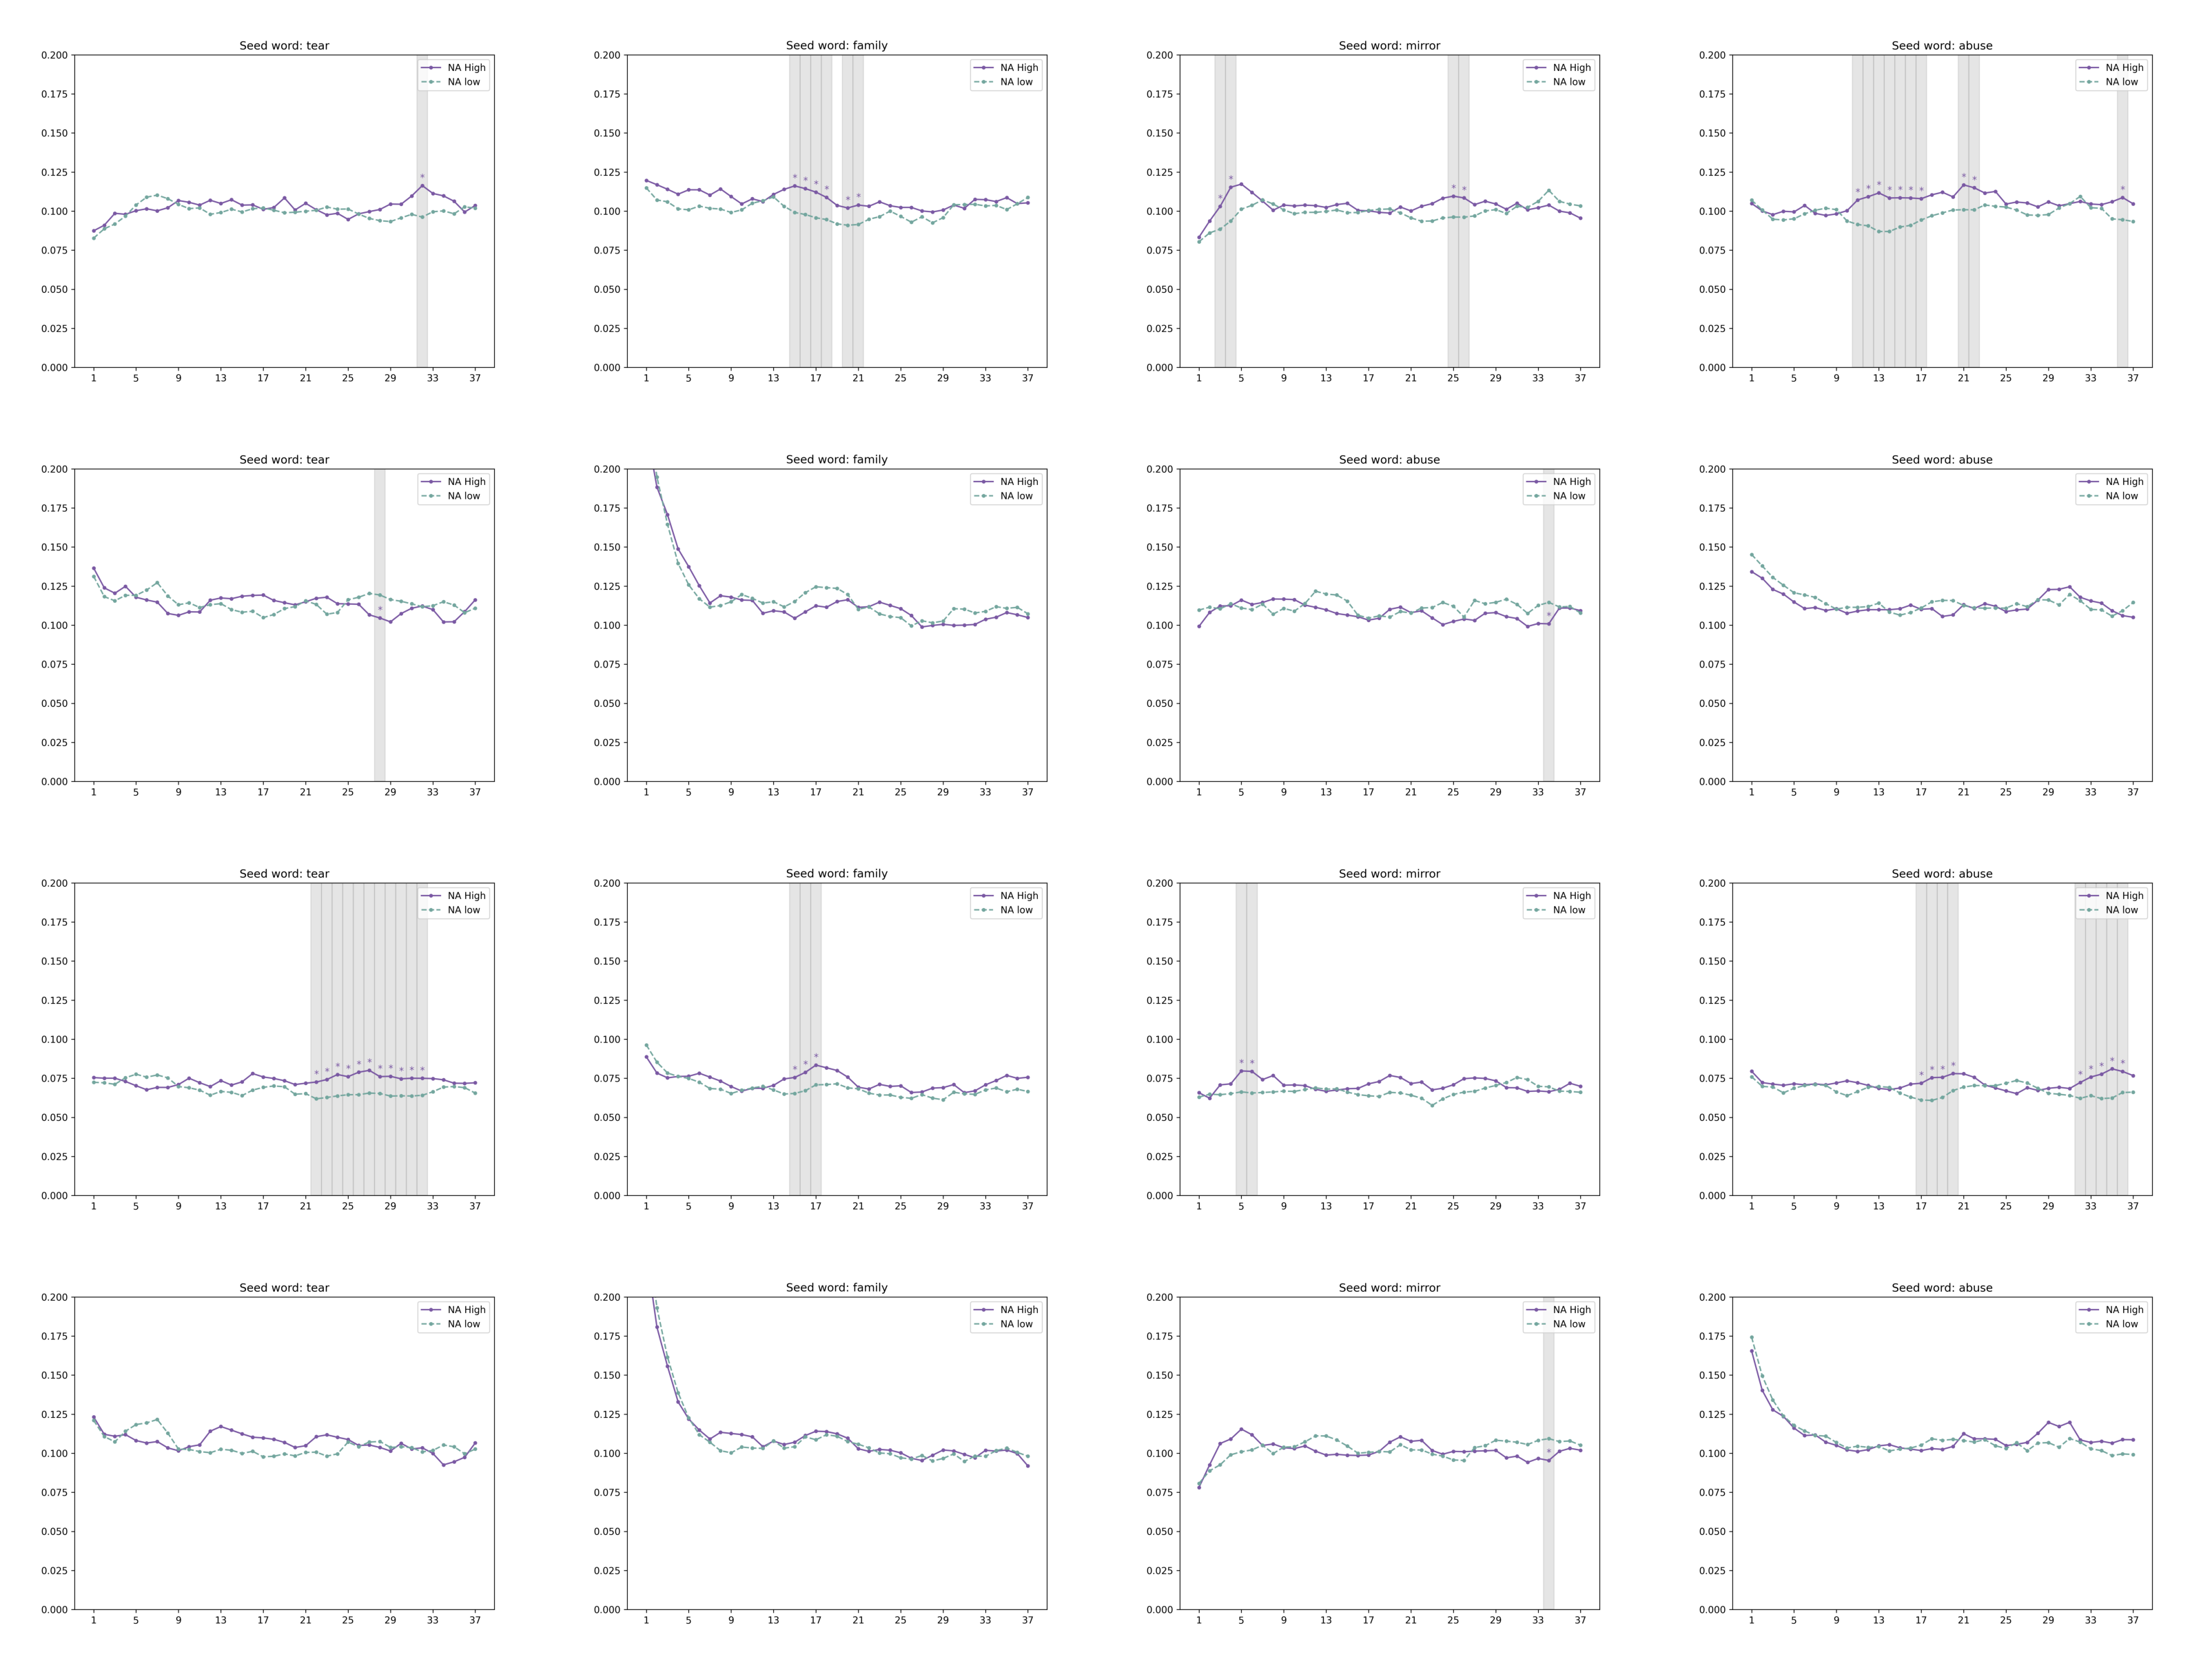

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(4, 4, figsize=(32, 24), constrained_layout=True)
plt.subplots_adjust(top=0, wspace=0, hspace=0)

ax = axes.flatten()

seed_words = ['tear', 'family', 'mirror', 'abuse']
target_words = ['money', 'friend', 'relationships', 'family']

i = 0
for target in target_words:
    for seed in seed_words:
        # 이미지 불러오기
        img = mpimg.imread(f'/Users/ihyeseung/git/FAST_word2vec/research1/graph/ancova/line_graph_{seed}_{target}.png')
        
        ax[i].imshow(img)
        ax[i].axis('off')

        i += 1
# 전체 그리드 이미지를 저장
filepath =  (f'\\{graph_image_dir}\\similarity_line_graph_{target}.png' if os_system == 'Windows' else f'/{graph_image_dir}/similarity_line_graph_{target}.png')
plt.savefig(filepath, dpi=300)

# 화면에 그리드 이미지 표시
plt.show()


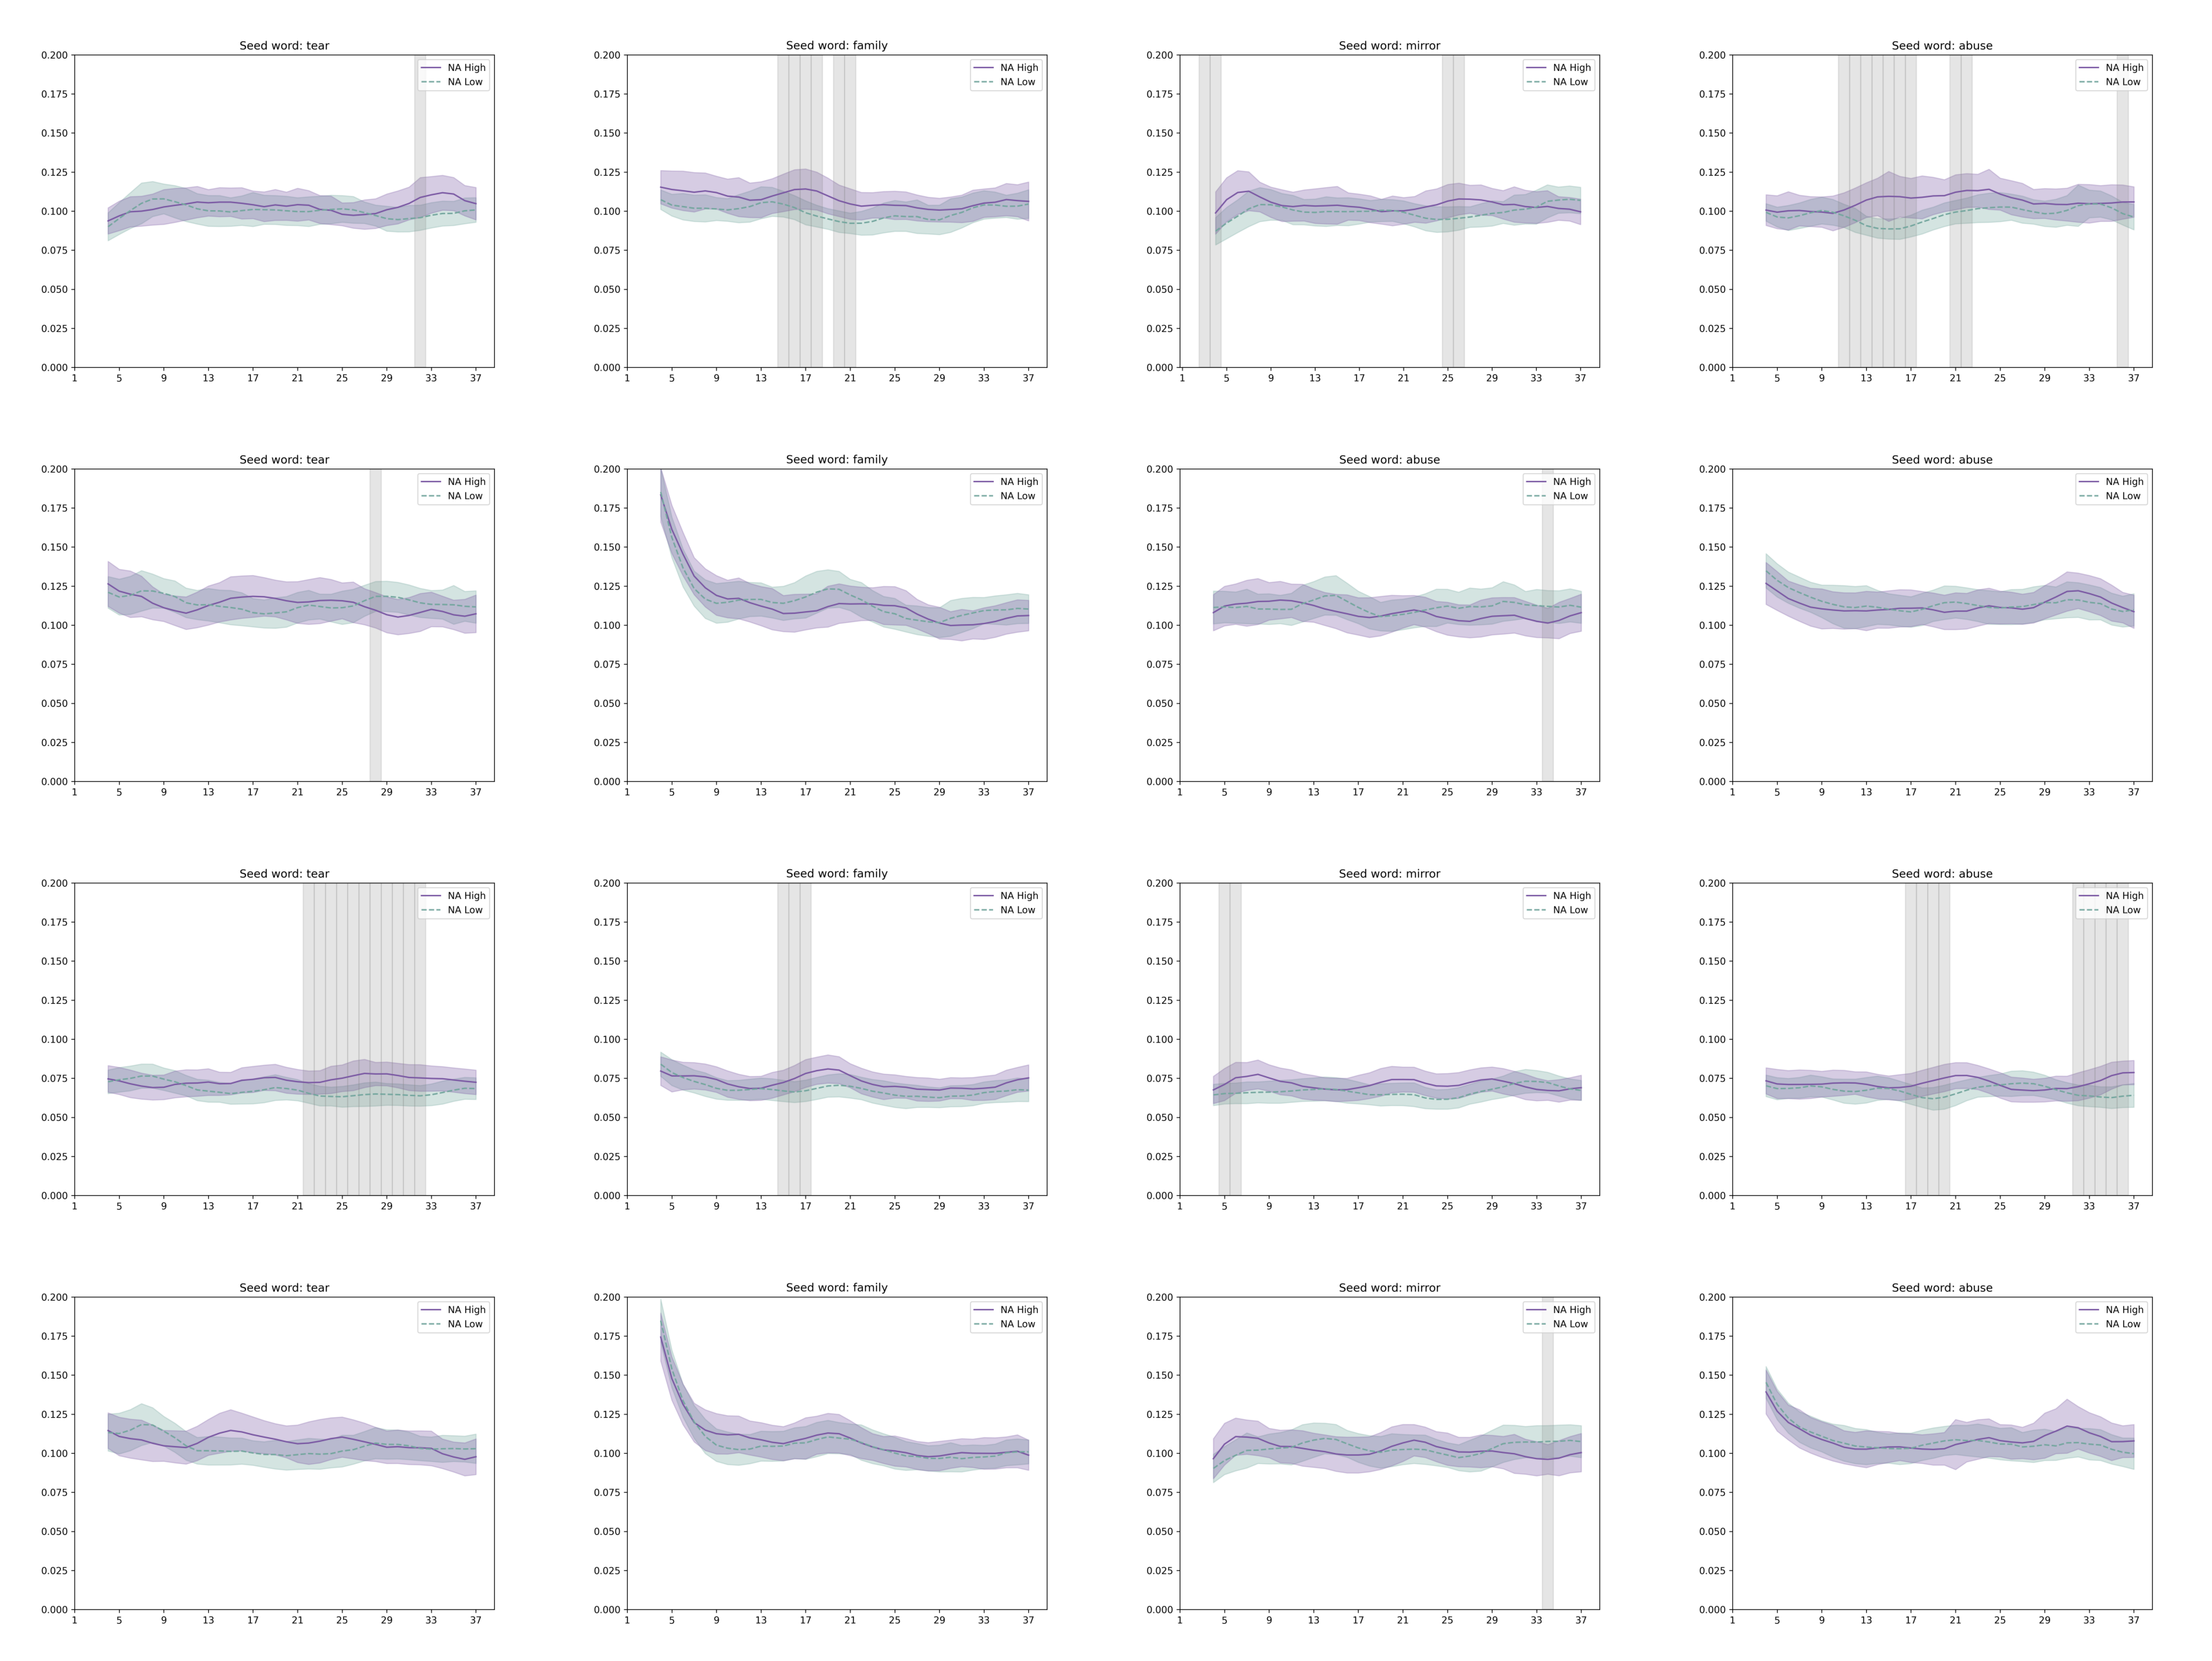

In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

fig, axes = plt.subplots(4, 4, figsize=(32, 24), constrained_layout=True)
plt.subplots_adjust(top=0, wspace=0, hspace=0)

ax = axes.flatten()

seed_words = ['tear', 'family', 'mirror', 'abuse']
target_words = ['money', 'friend', 'relationships', 'family']

i = 0
for target in target_words:
    for seed in seed_words:
        # 이미지 불러오기
        img = mpimg.imread(f'/Users/ihyeseung/git/FAST_word2vec/research1/graph/ancova/smoothing_graph_{seed}_{target}.png')
        
        ax[i].imshow(img)
        ax[i].axis('off')

        i += 1
# 전체 그리드 이미지를 저장
filepath =  (f'\\{graph_image_dir}\\similarity_line_graph_{target}.png' if os_system == 'Windows' else f'/{graph_image_dir}/similarity_line_graph_{target}.png')
plt.savefig(filepath, dpi=300)

# 화면에 그리드 이미지 표시
plt.show()
